In [1]:
import os
import numpy as np
from scipy import fftpack
import matplotlib.pyplot as plt

np.random.seed(42)

#data_dir = "/project/astro/sbi_lab/data/"
data_dir = "."
figs_dir = os.path.join(os.getcwd(), "grf_figs/") # Change this to your specification

for _path in [data_dir, figs_dir]:
    if not os.path.exists(_path):
        os.makedirs(_path, exist_ok=True)

In [2]:
from power import _get_k
def make_gaussian_random_field(n_pix, box_dim, power_spectrum, random_seed=None):
    '''
        Generate a Gaussian random field with the specified
        power spectrum.
        
        Parameters:
            * dims (tuple): the dimensions of the field in number
                of cells. Can be 2D or 3D.
            * box_dims (float or tuple): the dimensions of the field
                in cMpc.
            * power_spectrum (callable, one parameter): the desired 
                spherically-averaged power spectrum of the output.
                Given as a function of k
            * random_seed (int): the seed for the random number generation
                
        Returns:
            The Gaussian random field as a numpy array
    '''
    dims = (n_pix, n_pix)
    box_dims = [box_dim] * len(dims)
    assert len(dims) == 2 

    if random_seed != None:
        np.random.seed(random_seed)
    
    # Generate map in Fourier space, Gaussian distributed real and imaginary parts 
    # (= uniform amplitude, Gaussian phases). This field has P(k) = 1 for all k.
    map_ft_real = np.random.normal(loc=0., scale=1., size=dims)
    map_ft_imag = np.random.normal(loc=0., scale=1., size=dims)
    map_ft = map_ft_real + 1j * map_ft_imag

    # Get k modes for power spectrum, radially symmetric for homog. + iso. field.
    kx_ky, k = _get_k(map_ft_real, box_dims) # Get k values given dimensions of field

    # Numerical stability
    # k[np.abs(k) < 1.e-6] = 1.e-6
    
    # Scale factor
    boxvol = np.prod(box_dims) # = L^n_dims
    pixelsize = boxvol / (np.prod(map_ft_real.shape))
    scale_factor = pixelsize ** 2 / boxvol
    
    # Scale Fourier map by power spectrum (e.g. scale by covariance: same as reparameterization trick d_k = mu_k + noise * cov_k)
    map_ft *= np.sqrt(power_spectrum(k) / scale_factor) # Covariance scales with volume dictated by scale factor?
    
    # Inverse FT the Fourier space realisation that has been scaled by power-spectrum covariance
    map_ift = fftpack.ifftn(fftpack.fftshift(map_ft))
    
    # Real part of field
    map_real = np.real(map_ift)
    return map_real

In [3]:
from power import power_spectrum_1d

In [4]:
# Generate a multi cosmology dataset    
n_sims = 5_000
n_pix = 64
box_dim = 1.
pk_fn = lambda k: A * k ** -B

AB = np.array([1., 2.5]) # Fiducial cosmology
lower = np.array([0.1, 2.])
upper = np.array([2., 3.])
param_names = ["A", "B"]

parameters = np.stack(
    [
        np.random.uniform(low=lower[0], high=upper[0], size=n_sims),
        np.random.uniform(low=lower[1], high=upper[1], size=n_sims)
    ], 
    axis=1
)

parameters.shape

(5000, 2)

In [14]:
n_kbin = 50
fields = np.zeros((n_sims, n_pix, n_pix))
powers = np.zeros((n_sims, n_kbin))
modes = np.zeros((n_sims, n_kbin))
for i, y in enumerate(parameters):
    A, B = y
    pk_fn = lambda k: A * k ** -B
    field = make_gaussian_random_field(n_pix, box_dim, pk_fn, random_seed=i)
    fields[i] = field
    powerspec, _, mode = power_spectrum_1d(field, box_dim=box_dim, kbins=n_kbin)
    powers[i] = powerspec
    modes[i] = mode
    print(f"\r{i=} {field.max()=}, {field.min()=}", end="")

# Unpack true parameters, parameterise power spectrum model using them
A, B = AB
pk_fn = lambda k: A * k ** -B

# Make a measurement using the true parameters
data = make_gaussian_random_field(n_pix, box_dim, pk_fn, random_seed=1289738745)
data_powerspec, k, data_modes = power_spectrum_1d(data, box_dim=box_dim, kbins=n_kbin)

i=4999 field.max()=1.0723473204707732, field.min()=-0.650379714992349595

In [15]:
path = os.path.join(data_dir, f"data_{n_pix=}.npz")
np.savez(path, fields=fields, data=data,
         k=k, powers=powers, modes=modes,
         data_powerspec = data_powerspec, data_modes = data_modes,
         parameters = parameters)

/home/nilsor/data/PROJECTS/jed/STUDENT_LAB/power.py:99: RuntimeWarning: invalid value encountered in divide
  outdata /= n_modes


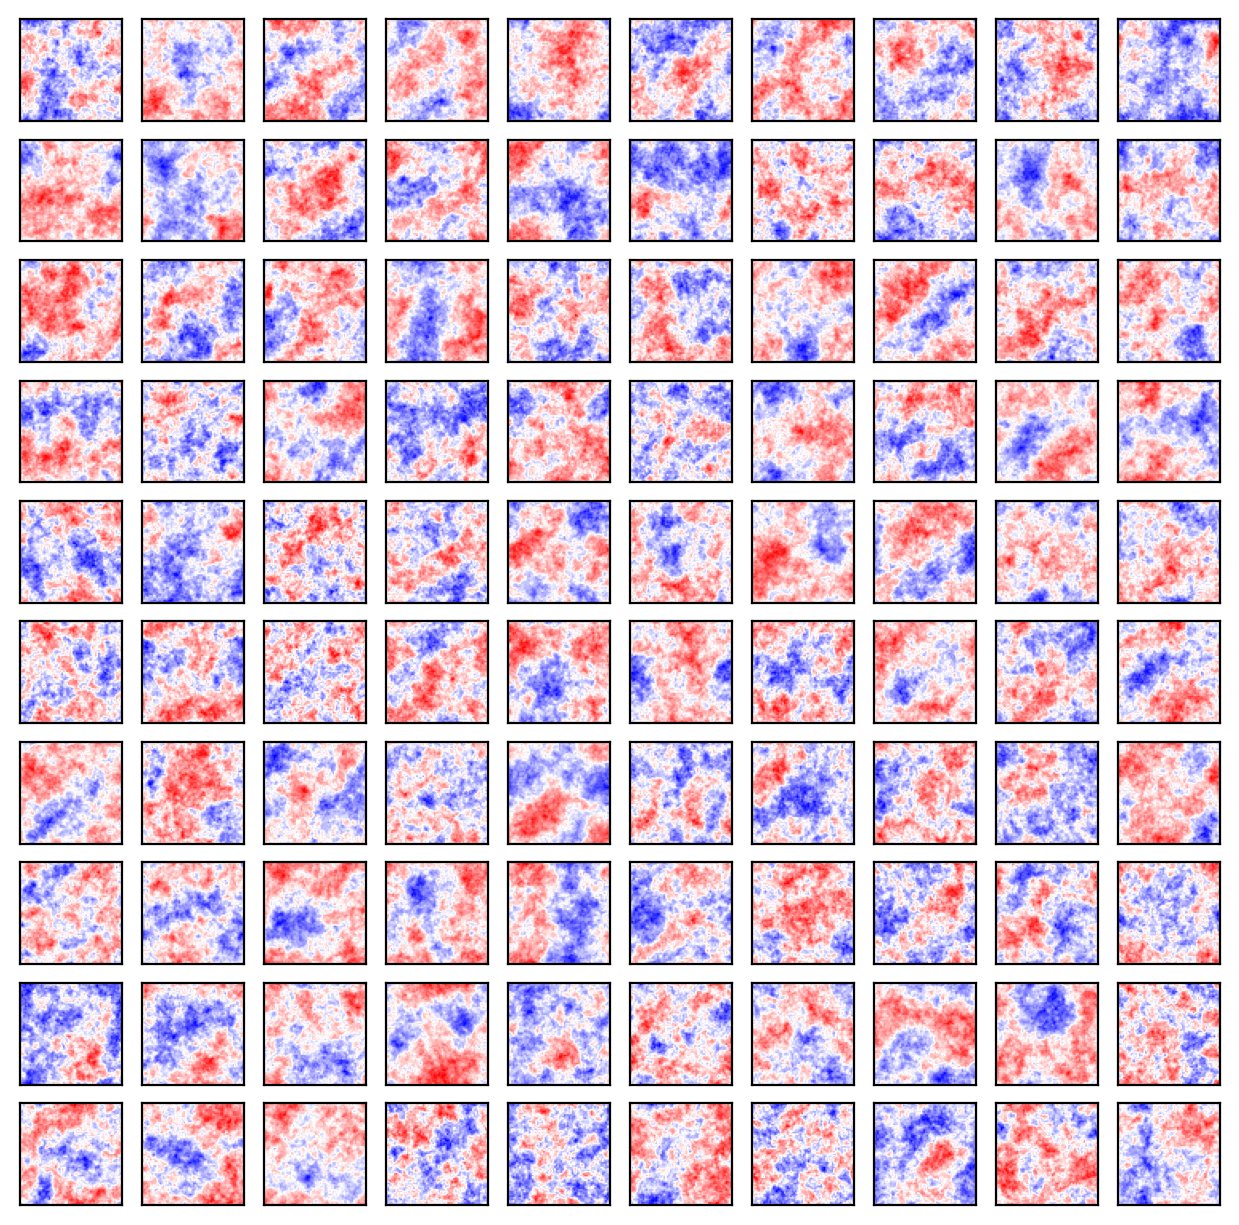

In [7]:
n_draws = 100

fig, axd = plt.subplot_mosaic(
    np.asarray([str(n) for n in range(100)]).reshape(10, 10), 
    figsize=(6., 6.),
    dpi=200,
    subplot_kw={"xticks" : [], "yticks" : []},
    gridspec_kw={
        "hspace" : 0.04, "left" : 0.0, "right" : 1.0, "top" : 1., "bottom" : 0.
    }
)

pks = np.zeros((n_draws, 100))
for i in range(n_draws):
    x = make_gaussian_random_field(
        n_pix=n_pix,
        box_dim=box_dim,
        power_spectrum=pk_fn,
        random_seed=i
    ) 

    pk, k, modes = power_spectrum_1d(x, box_dim=box_dim, kbins=100)
    pks[i] = pk

    axd[str(i)].imshow(x, cmap="bwr")

plt.savefig(os.path.join(figs_dir, "grfs.png"))
plt.show()

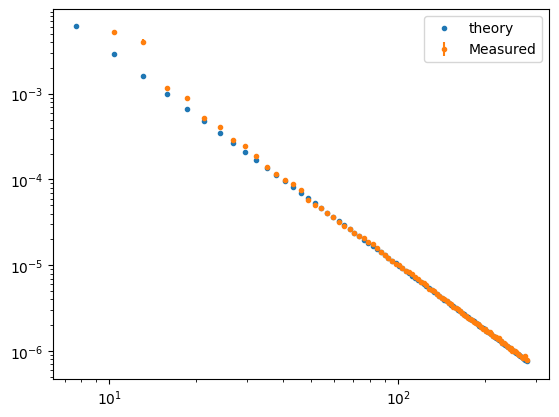

In [8]:
plt.figure()
plt.plot(k, pk_fn(k), marker=".", linestyle="", label="theory")
plt.errorbar(k, pks.mean(axis=0), yerr=pks.std(axis=0) / np.sqrt(n_draws), marker=".", linestyle="", label="Measured")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.savefig(os.path.join(figs_dir, "Pk_fid.png"), bbox_inches="tight")
plt.show()

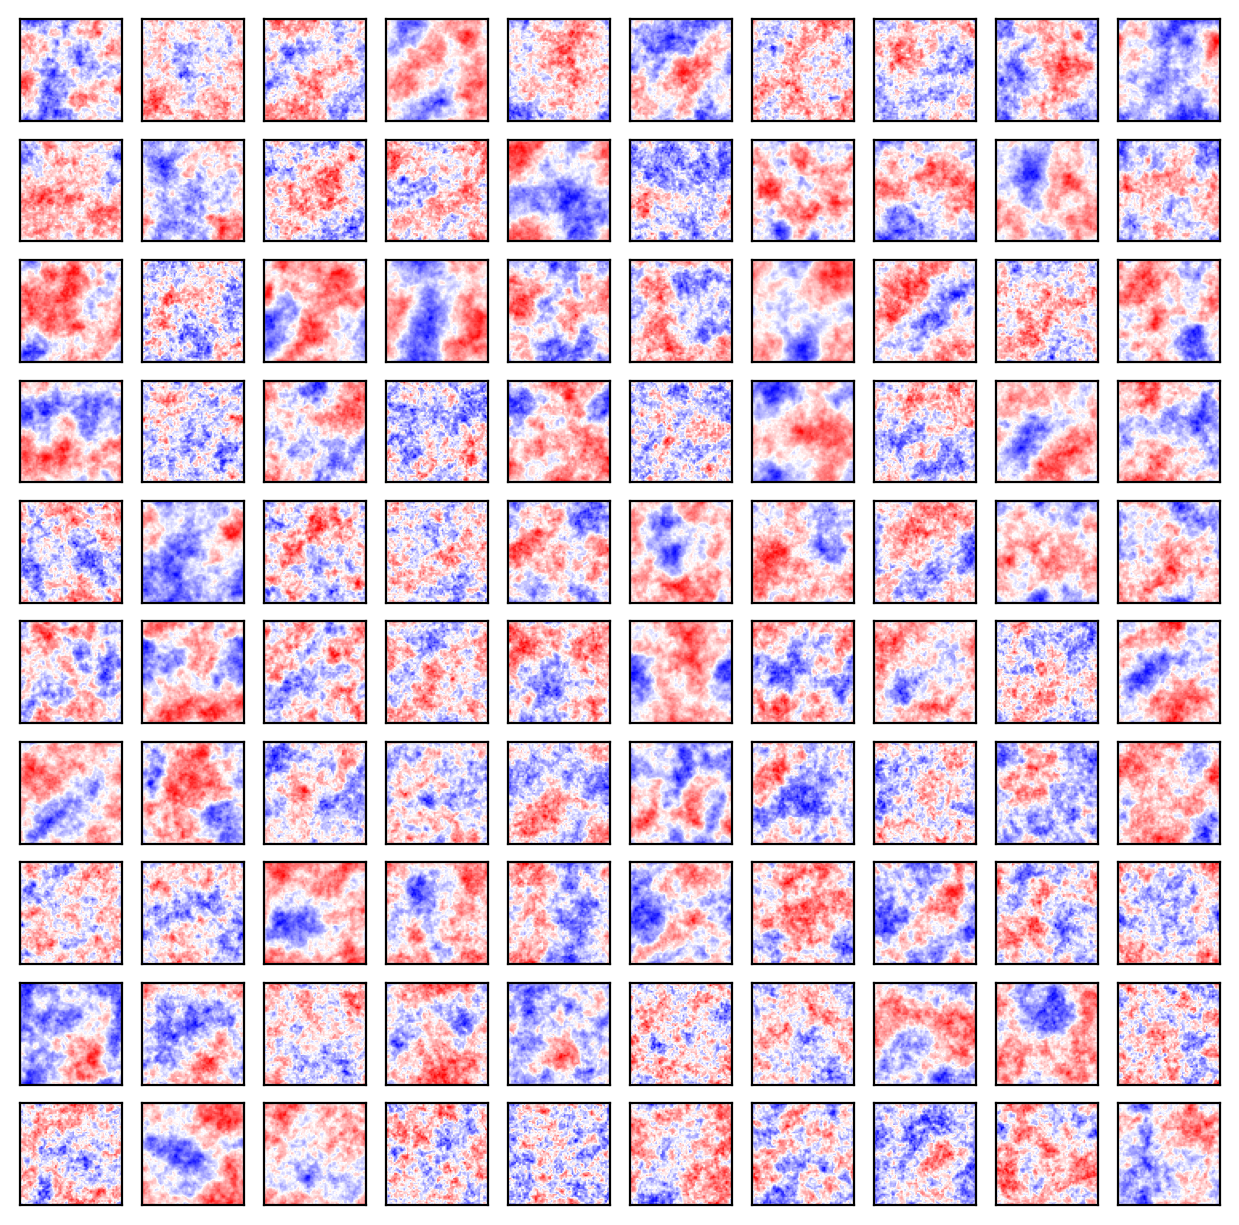

In [9]:
fig, axd = plt.subplot_mosaic(
    np.asarray([str(n) for n in range(100)]).reshape(10, 10), 
    figsize=(6., 6.),
    dpi=200,
    subplot_kw={"xticks" : [], "yticks" : []},
    gridspec_kw={
        "hspace" : 0.04, "left" : 0.0, "right" : 1.0, "top" : 1., "bottom" : 0.
    }
)

pks_multi_cos = np.zeros((n_draws, 50))
for i in range(n_draws):
    
    A, B = parameters[i]

    # Power spectrum model with sampled parameters
    pk_fn = lambda k: A * k ** -B

    x = make_gaussian_random_field(
        n_pix,
        box_dim=box_dim,
        power_spectrum=pk_fn,
        random_seed=i
    ) 

    pk, k, modes = power_spectrum_1d(x, box_dim=box_dim, kbins=50)
    pks_multi_cos[i] = pk

    axd[str(i)].imshow(x, cmap="bwr")

plt.savefig(os.path.join(figs_dir, "multi_cosmo_grfs.png"), bbox_inches="tight")
plt.show()

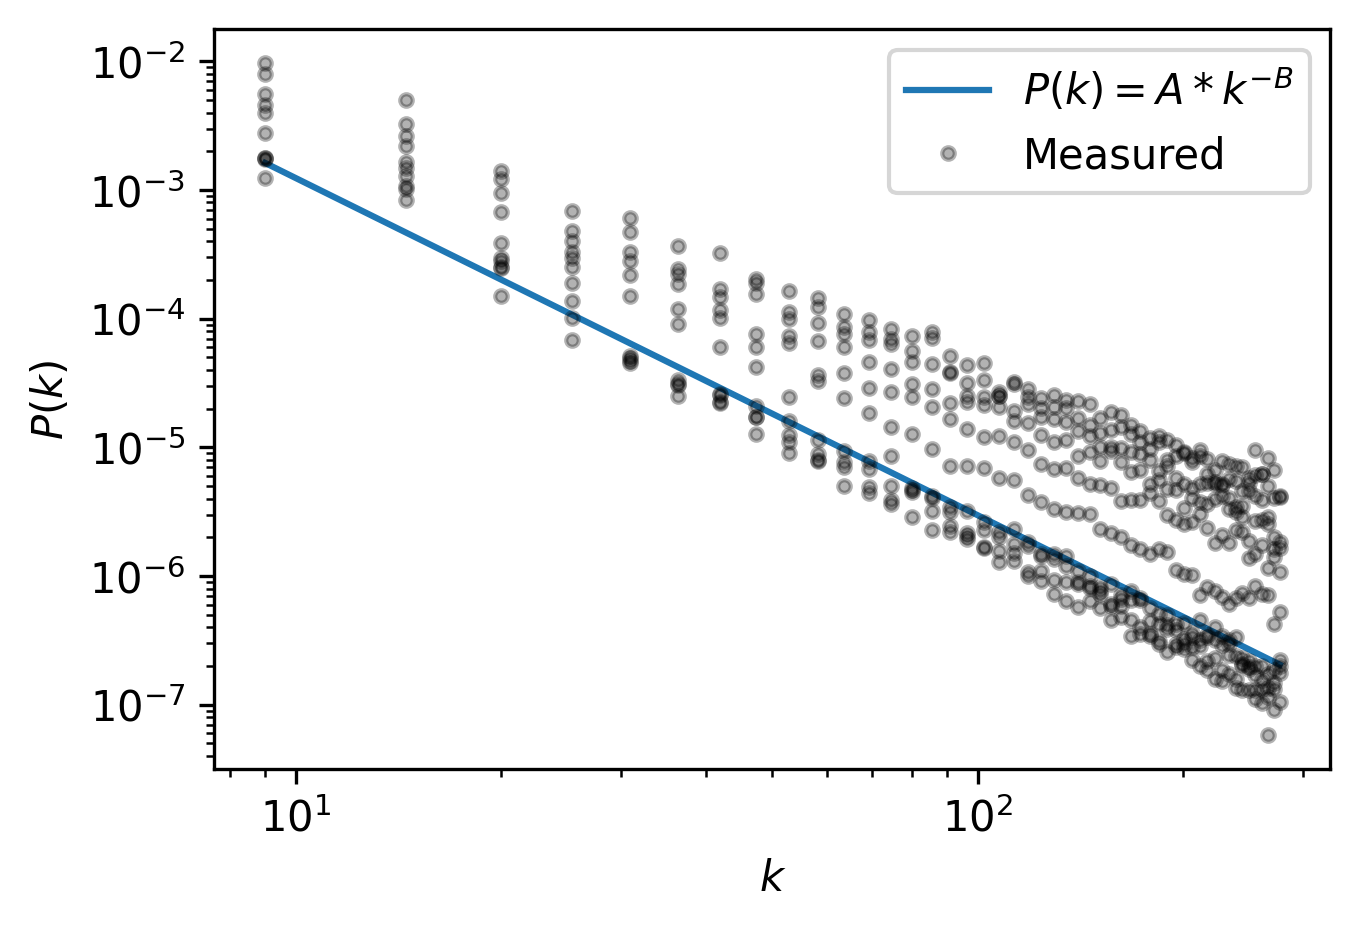

In [10]:
plt.figure(dpi=300, figsize=(4.8, 3.2))
plt.plot(k, pk_fn(k), label="$P(k)=A * k^{-B}$") 
for i in range(10):
    plt.plot(
        k, 
        pks_multi_cos[i], 
        marker=".", 
        linestyle="", 
        alpha=0.3,
        color="k", 
        label="Measured" if i == 0 else None
    )
plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.savefig(os.path.join(figs_dir, "multi_cosmo_pk.png"), bbox_inches="tight")
plt.show()